In [2]:
import pandas as pd
df = pd.read_csv(
    "Dataset/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)
df.shape

(5572, 2)

In [3]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [6]:
df["label_num"] = df["label"].map({
    "ham":0,
    "spam":1
})
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [7]:
df["label_num"].value_counts()

label_num
0    4825
1     747
Name: count, dtype: int64

In [8]:
import string
import nltk 
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

In [9]:
def clean_text(text):
    text = text.lower()

    cleaned_text = ""

    for char in text:
        if char not in string.punctuation:
            cleaned_text += char

    tokens = cleaned_text.split()

    filtered_message = []

    for word in tokens:
        if word not in stop_words:
            filtered_message.append(word)

    return filtered_message

In [10]:
df["cleaned_message"] = df["message"].apply(clean_text)
df[["message", "cleaned_message"]].head()

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...","[go, jurong, point, crazy, available, bugis, n..."
1,Ok lar... Joking wif u oni...,"[ok, lar, joking, wif, u, oni]"
2,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,U dun say so early hor... U c already then say...,"[u, dun, say, early, hor, u, c, already, say]"
4,"Nah I don't think he goes to usf, he lives aro...","[nah, dont, think, goes, usf, lives, around, t..."


In [11]:
df["message_length"] = df["message"].apply(len)
df[["message", "message_length"]].head()

,message,message_length
0,"Go until jurong point, crazy.. Available only ...",111
1,Ok lar... Joking wif u oni...,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,U dun say so early hor... U c already then say...,49
4,"Nah I don't think he goes to usf, he lives aro...",61


In [12]:
df["digit_count"] = df["message"].apply(
    lambda x: sum(char.isdigit() for char in x)
)
df[["message", "digit_count"]].head()

,message,digit_count
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,25
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [13]:
df["special_char_count"] = df["message"].apply(
    lambda x: sum(char in string.punctuation for char in x)
)
df[["message", "special_char_count"]].head()

,message,special_char_count
0,"Go until jurong point, crazy.. Available only ...",9
1,Ok lar... Joking wif u oni...,6
2,Free entry in 2 a wkly comp to win FA Cup fina...,6
3,U dun say so early hor... U c already then say...,6
4,"Nah I don't think he goes to usf, he lives aro...",2


In [14]:
import re
df["url_count"] = df["message"].apply(
    lambda x: len(re.findall(r'http\S+|www\S+', x))
)
df[["message", "url_count"]].head(13)

,message,url_count
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,0
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0
5,FreeMsg Hey there darling it's been 3 week's n...,0
6,Even my brother is not like to speak with me. ...,0
7,As per your request 'Melle Melle (Oru Minnamin...,0
8,WINNER!! As a valued network customer you have...,0
9,Had your mobile 11 months or more? U R entitle...,0


In [15]:
df.groupby("label")[[
    "message_length",
    "digit_count",
    "special_char_count",
    "url_count"
]].mean()

,message_length,digit_count,special_char_count,url_count
label,,,,
ham,71.482487,0.305285,3.939896,0.000415
spam,138.670683,15.812584,5.712182,0.140562


In [16]:
from sklearn.model_selection import train_test_split 
X = df["message"]
y = df["label_num"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4457,)
(1115,)
(4457,)
(1115,)


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [18]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4457, 7702)
(1115, 7702)


In [19]:
from scipy.sparse import hstack

X_train_combined = hstack((
    X_train_tfidf,
    df.loc[X_train.index, [
        "message_length",
        "digit_count",
        "special_char_count",
        "url_count"
    ]]
))

In [20]:
X_test_combined = hstack((
    X_test_tfidf,
    df.loc[X_test.index, [
        "message_length",
        "digit_count",
        "special_char_count",
        "url_count"
    ]]
))      

In [21]:
print(X_train_combined.shape)
print(X_test_combined.shape)

(4457, 7706)
(1115, 7706)


In [22]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train_combined, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [23]:
y_pred = model.predict(X_test_combined)

In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [25]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.9739910313901345


In [26]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("TN: ",cm[0][0])
print("FP: ",cm[0][1])
print("FN: ",cm[1][0])
print("TP: ",cm[1][1])

[[959   7]
 [ 22 127]]
TN:  959
FP:  7
FN:  22
TP:  127


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       966
           1       0.95      0.85      0.90       149

    accuracy                           0.97      1115
   macro avg       0.96      0.92      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [28]:
from sklearn.model_selection import cross_val_score

Score = cross_val_score(
    MultinomialNB(),
    X_train_combined,
    y_train,
    cv=5
)
print(Score)
print("Average CV Score: ",Score.mean())

[0.97085202 0.98430493 0.97306397 0.9708193  0.96071829]
Average CV Score:  0.9719517043881767


In [29]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    C=5
)
lr_model.fit(X_train_combined, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,5
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
lr_pred = lr_model.predict(X_test_combined)
lr_accuracy = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9901345291479821


In [31]:
lr_cm = confusion_matrix(y_test, lr_pred)
print(lr_cm)
print("lr TN:", lr_cm[0][0])
print("lr FP:", lr_cm[0][1])
print("lr FN:", lr_cm[1][0])
print("lr TP:", lr_cm[1][1])

[[963   3]
 [  8 141]]
lr TN: 963
lr FP: 3
lr FN: 8
lr TP: 141


In [32]:
lr_report = classification_report(y_test, lr_pred)
print("Logistic Regression Classification Report:", lr_report)

Logistic Regression Classification Report:               precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.98      0.95      0.96       149

    accuracy                           0.99      1115
   macro avg       0.99      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [41]:
from sklearn.metrics import roc_auc_score

lr_probs = lr_model.predict_proba(X_test_combined)[:, 1]
roc_auc = roc_auc_score(y_test, lr_probs)
print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9959


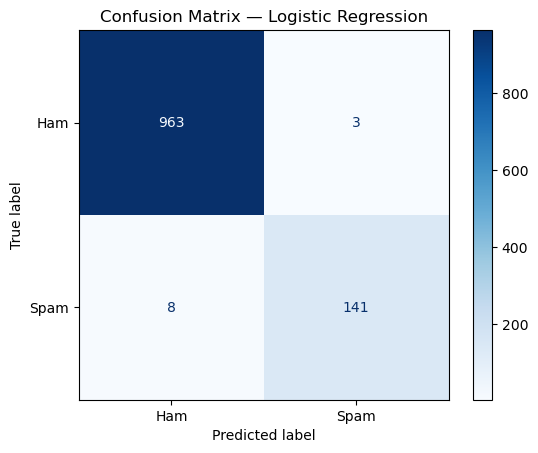

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["Ham", "Spam"],
    cmap="Blues"
)
plt.title("Confusion Matrix — Logistic Regression")
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [43]:
lr_score = cross_val_score(
    LogisticRegression(
        max_iter=1000
    ),
    X_train_combined,
    y_train,
    cv=5
)
print(lr_score)
print("LR Average Score:", lr_score.mean())

[0.98318386 0.98991031 0.97306397 0.97306397 0.97418631]
LR Average Score: 0.9786816848102349


In [44]:
comparison = {
    "Model": [
        "Naive Bayes",
        "Logistic Regression(Balanced)"
    ],

    "Accuracy": [
        0.973991,
        00.99013
    ],

    "Recall": [
        0.85,
        0.95
    ]
}
comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy,Recall
0,Naive Bayes,0.973991,0.85
1,Logistic Regression(Balanced),0.990130,0.95


In [45]:
final_model = lr_model
print("Final Model Selected: Logistic Regression")

Final Model Selected: Logistic Regression


In [46]:
import pickle
with open("Models/spam_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

with open("Models/tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

In [47]:
with open("Models/spam_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)
print("Model Loaded Succesfully")
with open("Models/tfidf_vectorizer.pkl", "rb") as file:
    loaded_tfidf = pickle.load(file)
print("Tfidf Loaded Sucessfully")

Model Loaded Succesfully
Tfidf Loaded Sucessfully
